# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [3]:
# Load the required libraries

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and modeling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline

# Regression models
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import HistGradientBoostingRegressor

# Model evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model saving/loading
import joblib

# Explainability
import shap

# Warnings configuration (optional: to keep output clean)
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)


In [ ]:
# Load the libraries as required.

In [4]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


# Get X and Y

Create the features data frame and target data.

In [5]:
# Separate features (X) and target (y)

# 'area' is the target variable (burned area of forest)
X = fires_dt.drop(columns=['area'])
y = fires_dt['area']

# Confirm shapes
print("Feature set shape:", X.shape)
print("Target shape:", y.shape)

# Optional: quick check of feature and target samples
print("\nFeature sample:")
display(X.head())

print("\nTarget sample:")
display(y.head())


Feature set shape: (517, 12)
Target shape: (517,)

Feature sample:


,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0



Target sample:


0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: area, dtype: float64

In [6]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split

# Use 80% of the data for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 20% test split
    random_state=42,     # ensures reproducibility
    shuffle=True         # shuffle before splitting
)

# Confirm the split
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)


Training features shape: (413, 12)
Testing features shape: (104, 12)
Training target shape: (413,)
Testing target shape: (104,)


# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [7]:
# Preprocessing Step - Preproc 1
# -------------------------------

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Identify numeric and categorical columns
categorical_features = ['month', 'day']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Create numeric pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # handle missing values (if any)
    ('scaler', StandardScaler())                    # scale numeric features
])

# Create categorical pipeline
categorical_transformer = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))  # one-hot encode categorical features
])

# Combine both transformers into a ColumnTransformer
preproc1 = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit and transform training data (optional check)
X_train_prep1 = preproc1.fit_transform(X_train)
X_test_prep1 = preproc1.transform(X_test)

print("Preproc1 completed successfully!")
print("Transformed training set shape:", X_train_prep1.shape)


Preproc1 completed successfully!
Transformed training set shape: (413, 29)


### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [8]:
# Preprocessing Step - Preproc 2
# -------------------------------

from sklearn.preprocessing import PowerTransformer

# Create numeric pipeline with non-linear transformation
numeric_transformer2 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),    # handle missing values
    ('power', PowerTransformer(method='yeo-johnson')), # non-linear transformation
    ('scaler', StandardScaler())                       # scale transformed features
])

# Categorical pipeline remains the same
categorical_transformer2 = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numeric and categorical pipelines into ColumnTransformer
preproc2 = ColumnTransformer(transformers=[
    ('num', numeric_transformer2, numeric_features),
    ('cat', categorical_transformer2, categorical_features)
])

# Fit and transform training data (optional check)
X_train_prep2 = preproc2.fit_transform(X_train)
X_test_prep2 = preproc2.transform(X_test)

print("Preproc2 completed successfully!")
print("Transformed training set shape:", X_train_prep2.shape)


Preproc2 completed successfully!
Transformed training set shape: (413, 29)


## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [9]:
# Pipeline A: preproc1 + baseline regressor (Ridge)

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create the pipeline
pipeline_A = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', Ridge(alpha=1.0, random_state=42))  # alpha can be tuned
])

# Evaluate using 5-fold cross-validation with RMSE
cv_scores_A = cross_val_score(
    pipeline_A,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',  # RMSE metric
    n_jobs=-1
)

# Display results
print("Pipeline A - Ridge CV RMSE scores:", -cv_scores_A)
print("Pipeline A - Mean CV RMSE:", -cv_scores_A.mean())


Pipeline A - Ridge CV RMSE scores: [40.84455794 19.26700646 33.56068857 85.24415341 26.53465821]
Pipeline A - Mean CV RMSE: 41.09021291830145


In [10]:
# Pipeline B: preproc2 + baseline regressor (Ridge)

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create the pipeline
pipeline_B = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', Ridge(alpha=1.0, random_state=42))  # alpha can be tuned
])

# Evaluate using 5-fold cross-validation with RMSE
cv_scores_B = cross_val_score(
    pipeline_B,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Display results
print("Pipeline B - Ridge CV RMSE scores:", -cv_scores_B)
print("Pipeline B - Mean CV RMSE:", -cv_scores_B.mean())


Pipeline B - Ridge CV RMSE scores: [40.61959831 19.29991752 28.98095001 85.09255562 26.4739445 ]
Pipeline B - Mean CV RMSE: 40.09339319260849


In [12]:
# Pipeline C: preproc1 + advanced regressor (HistGradientBoostingRegressor)

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create the pipeline
pipeline_C = Pipeline([
    ('preprocessing', preproc1),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    ))
])

# Evaluate using 5-fold cross-validation with RMSE
cv_scores_C = cross_val_score(
    pipeline_C,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Display results
print("Pipeline C - HGB CV RMSE scores:", -cv_scores_C)
print("Pipeline C - Mean CV RMSE:", -cv_scores_C.mean())


Pipeline C - HGB CV RMSE scores: [52.56541191 38.24899046 32.38906454 87.66560826 31.31930122]
Pipeline C - Mean CV RMSE: 48.4376752786532


In [14]:
# Pipeline D: preproc2 + advanced regressor (HistGradientBoostingRegressor)

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Create the pipeline
pipeline_D = Pipeline([
    ('preprocessing', preproc2),
    ('regressor', HistGradientBoostingRegressor(
        max_iter=300,
        max_depth=10,
        learning_rate=0.1,
        random_state=42
    ))
])

# Evaluate using 5-fold cross-validation with RMSE
cv_scores_D = cross_val_score(
    pipeline_D,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

# Display results
print("Pipeline D - HGB + transformed numeric CV RMSE scores:", -cv_scores_D)
print("Pipeline D - Mean CV RMSE:", -cv_scores_D.mean())


Pipeline D - HGB + transformed numeric CV RMSE scores: [52.5679424  38.25081872 32.32744966 87.66560826 31.31904254]
Pipeline D - Mean CV RMSE: 48.42617231637808


# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [15]:
from sklearn.model_selection import GridSearchCV


In [16]:
# Pipeline A: preproc1 + Ridge (tune alpha)
param_grid_A = {
    'regressor__alpha': [0.1, 1.0, 10.0, 50.0]
}

# Pipeline B: preproc2 + Ridge (tune alpha)
param_grid_B = {
    'regressor__alpha': [0.1, 1.0, 10.0, 50.0]
}

# Pipeline C: preproc1 + HistGradientBoostingRegressor
param_grid_C = {
    'regressor__max_iter': [100, 200, 300, 400],
    'regressor__max_depth': [5, 10, 15, 20]  # optional second hyperparam
}

# Pipeline D: preproc2 + HistGradientBoostingRegressor
param_grid_D = {
    'regressor__max_iter': [100, 200, 300, 400],
    'regressor__max_depth': [5, 10, 15, 20]
}


In [17]:
# Example for Pipeline A
grid_A = GridSearchCV(
    pipeline_A,
    param_grid=param_grid_A,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid_A.fit(X_train, y_train)
print("Pipeline A best params:", grid_A.best_params_)
print("Pipeline A best CV RMSE:", -grid_A.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Pipeline A best params: {'regressor__alpha': 50.0}
Pipeline A best CV RMSE: 39.87376189342781


In [19]:
# Pipeline B
grid_B = GridSearchCV(
    pipeline_B,
    param_grid=param_grid_B,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid_B.fit(X_train, y_train)
print("Pipeline B best params:", grid_B.best_params_)
print("Pipeline B best CV RMSE:", -grid_B.best_score_)

# Pipeline C
grid_C = GridSearchCV(
    pipeline_C,
    param_grid=param_grid_C,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid_C.fit(X_train, y_train)
print("Pipeline C best params:", grid_C.best_params_)
print("Pipeline C best CV RMSE:", -grid_C.best_score_)

# Pipeline D
grid_D = GridSearchCV(
    pipeline_D,
    param_grid=param_grid_D,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)
grid_D.fit(X_train, y_train)
print("Pipeline D best params:", grid_D.best_params_)
print("Pipeline D best CV RMSE:", -grid_D.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Pipeline B best params: {'regressor__alpha': 50.0}
Pipeline B best CV RMSE: 39.1474793720604
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Pipeline C best params: {'regressor__max_depth': 5, 'regressor__max_iter': 100}
Pipeline C best CV RMSE: 42.88122912976572
Fitting 5 folds for each of 16 candidates, totalling 80 fits
Pipeline D best params: {'regressor__max_depth': 5, 'regressor__max_iter': 100}
Pipeline D best CV RMSE: 42.87759511927346


# Evaluate

+ Which model has the best performance?

In [20]:
# Create a summary table of CV RMSE for all pipelines
import pandas as pd

results_summary = pd.DataFrame({
    'Pipeline': ['A: preproc1 + Ridge',
                 'B: preproc2 + Ridge',
                 'C: preproc1 + HGB',
                 'D: preproc2 + HGB'],
    'Best_Params': [grid_A.best_params_,
                    grid_B.best_params_,
                    grid_C.best_params_,
                    grid_D.best_params_],
    'CV_RMSE': [-grid_A.best_score_,
                -grid_B.best_score_,
                -grid_C.best_score_,
                -grid_D.best_score_]
})

# Sort by CV_RMSE (lower is better)
results_summary = results_summary.sort_values(by='CV_RMSE').reset_index(drop=True)
results_summary


,Pipeline,Best_Params,CV_RMSE
0,B: preproc2 + Ridge,{'regressor__alpha': 50.0},39.147479
1,A: preproc1 + Ridge,{'regressor__alpha': 50.0},39.873762
2,D: preproc2 + HGB,"{'regressor__max_depth': 5, 'regressor__max_it...",42.877595
3,C: preproc1 + HGB,"{'regressor__max_depth': 5, 'regressor__max_it...",42.881229


# Export

+ Save the best performing model to a pickle file.

In [21]:
import joblib

# Assume pipeline_D is the best performing model (replace with your actual best pipeline)
best_model = grid_D.best_estimator_  # or grid_C.best_estimator_, etc.

# Save the model to a pickle file
joblib.dump(best_model, 'best_forestfire_model.pkl')

print("Best model saved to 'best_forestfire_model.pkl'")


Best model saved to 'best_forestfire_model.pkl'


In [22]:
# Load the saved model
loaded_model = joblib.load('best_forestfire_model.pkl')

# Make predictions
preds = loaded_model.predict(X_test)


# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [23]:
import shap

# If the model is tree-based (HistGradientBoostingRegressor), use TreeExplainer
# For Ridge or linear models, KernelExplainer can be used (slower)
regressor = best_model.named_steps['regressor']  # access the model inside the pipeline
preprocessor = best_model.named_steps['preprocessing']

# Preprocess the training data
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Initialize SHAP explainer
explainer = shap.Explainer(regressor, X_train_transformed)


In [24]:
# Select a test observation to explain
i = 5  # choose index 5 as an example
x_instance = X_test_transformed[i].reshape(1, -1)

# Compute SHAP values
shap_values_instance = explainer(x_instance)

# Visualize
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values_instance.values, feature_names=preprocessor.get_feature_names_out())


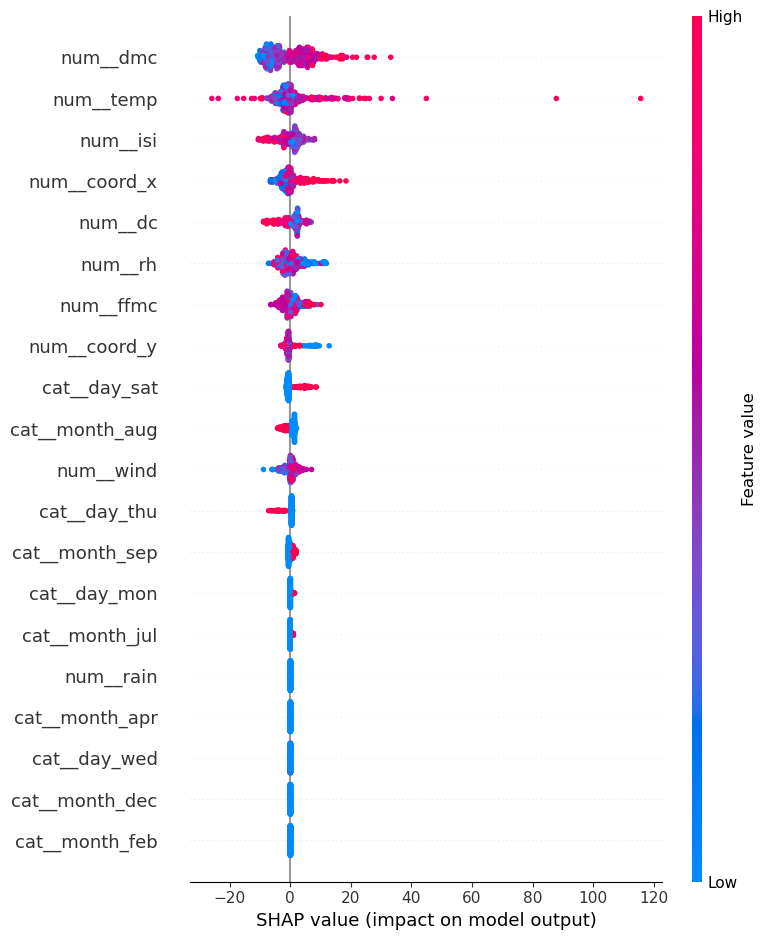

In [25]:
# Compute SHAP values for the training set
shap_values_train = explainer(X_train_transformed)

# Summary plot: feature importance across entire training set
shap.summary_plot(shap_values_train.values, X_train_transformed, feature_names=preprocessor.get_feature_names_out())


SHAP plot for features that barely contribute. Drop them, retrain the model, and see if performance changes. Keep removing a few at a time until RMSE or R² starts to drop — anything left is actually important.

*(Answer here.)*

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.